# MaxCut on IBM Quantum Hardware

This notebook runs the **Layer-VQE** algorithm for Max-Cut on real IBM quantum hardware
(or a local noise-model fake backend for testing).

## How src primitives map to IBM Runtime

| `src/` primitive | Role here |
|---|---|
| `MaxCut` | Problem definition, Hamiltonian terms, brute-force oracle |
| `Ansatz` | Parameterized circuit template (converted to Qiskit) |
| `COBYLA` / `SMO` | Classical outer optimizer |
| `LayerVQE` | Layer-by-layer optimization orchestrator |
| **IBM `Estimator`** | Replaces `QuimbSimulator.expectation()` on hardware |
| **IBM `Sampler`** | Replaces `QuimbSimulator.sample_expectation()` for final solution |

> **Hardware note:** each optimizer step submits one quantum job.
> Inside a `Session` these are queued back-to-back with minimal overhead.
> Use the fake backend (`USE_REAL_HARDWARE=false` in `.env`) to test locally first.

## Credentials setup

IBM Quantum credentials are loaded from a **`.env` file** at the project root — never hardcoded.

```
# .env  (gitignored — never commit this file)
IBM_QUANTUM_TOKEN=your_token_here
# Optional: CRN of your instance, e.g. crn:v1:bluemix:public:quantum-computing:us-east:a/...
# Leave blank to let the service pick your default instance.
IBM_QUANTUM_INSTANCE=
USE_REAL_HARDWARE=false
```

Copy `.env.example` → `.env` and fill in your token.  `.env` is already in `.gitignore`.

In [35]:
# Uncomment to install missing packages
# !pip install qiskit-ibm-runtime python-dotenv

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from dotenv import load_dotenv

# Project root is one level above notebooks/
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Load credentials from .env before any os.getenv() call
load_dotenv(PROJECT_ROOT / '.env')

# --- src primitives ---
from src.maxcut import MaxCut
from src.ansatze import Ansatz
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE

# --- Qiskit ---
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# --- IBM Runtime ---
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    Batch,
    EstimatorV2 as Estimator,
    SamplerV2   as Sampler,
)

print('All imports OK')

All imports OK


## Configuration

In [2]:
# ── Credentials (read from .env, never hardcoded) ─────────────────────────────
USE_REAL_HARDWARE = os.getenv("USE_REAL_HARDWARE", "false").strip().lower() == "true"
IBM_TOKEN         = os.getenv("IBM_QUANTUM_TOKEN", "")
IBM_INSTANCE      = os.getenv("IBM_QUANTUM_INSTANCE", "").strip()  # CRN; blank = use account default

# Guard: fail early if token is missing and real hardware was requested
if USE_REAL_HARDWARE and not IBM_TOKEN:
    raise EnvironmentError(
        "IBM_QUANTUM_TOKEN is not set. "
        "Add it to .env (copy .env.example -> .env) or set USE_REAL_HARDWARE=false."
    )

print(f"USE_REAL_HARDWARE : {USE_REAL_HARDWARE}")
print(f"IBM_INSTANCE      : {IBM_INSTANCE or '(default)'}")
token_status = "set" if IBM_TOKEN else "not set  (fake backend will be used)"
print(f"IBM_TOKEN         : {token_status}")

# ── Problem ───────────────────────────────────────────────────────────────────
SEED      = 42
NUM_NODES = 5       # C5 ring — 4 qubits after symmetry reduction; ideal for hardware

# ── L-VQE ─────────────────────────────────────────────────────────────────────
N_LAYERS    = 1     # extra layers added on top of layer 0
K_PER_LAYER = 30    # optimizer iters during layer-growing phase
K_FINAL     = 100   # optimizer iters in the final layer
OPTIMIZER   = COBYLA  # COBYLA or SMO

USE_REAL_HARDWARE : True
IBM_INSTANCE      : ibm-q/open/main
IBM_TOKEN         : set


## Problem: MaxCut on a small graph

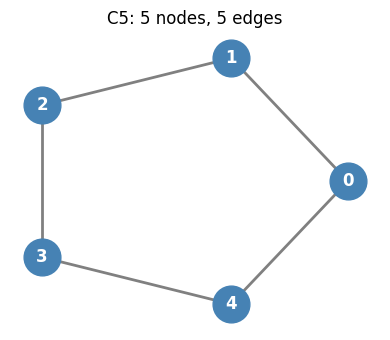

Qubits           : 4  (NUM_NODES − 1, qubit 0 pinned to partition 0)
Hamiltonian terms: 5
Best known cut   : 4.0  (brute-force, N ≤ 20)
Corresponding energy: 1.500

Hamiltonian terms:
  -0.500 × Z0
  -0.500 × Z3
  -0.500 × Z0 · Z1
  -0.500 × Z1 · Z2
  -0.500 × Z2 · Z3


In [3]:
np.random.seed(SEED)

G = nx.cycle_graph(NUM_NODES)   # C5 ring graph — MaxCut = 4 is known

fig, ax = plt.subplots(figsize=(4, 3.5))
pos = nx.circular_layout(G)
nx.draw(
    G, pos, ax=ax, with_labels=True,
    node_color='steelblue', node_size=700, font_color='white', font_weight='bold',
    edge_color='gray', width=2,
)
ax.set_title(f'C{NUM_NODES}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
plt.tight_layout()
plt.show()

problem = MaxCut(G, seed=SEED)
print(f'Qubits           : {problem.num_qubits}  (NUM_NODES − 1, qubit 0 pinned to partition 0)')
print(f'Hamiltonian terms: {len(problem.hamiltonian_terms)}')
print(f'Best known cut   : {problem.best_known_value}  (brute-force, N ≤ 20)')
print(f'Corresponding energy: {problem.cut_to_energy(problem.best_known_value):.3f}')
print()
print('Hamiltonian terms:')
for coeff, qubits in problem.hamiltonian_terms:
    label = ' · '.join(f'Z{q}' for q in qubits) if qubits else 'I'
    print(f'  {coeff:+.3f} × {label}')

## Translate `Ansatz` → Qiskit `QuantumCircuit`

`Ansatz.get_gates(params)` accepts any indexable sequence of angles.
Passing a `ParameterVector` instead of a NumPy array yields a fully symbolic
Qiskit circuit that can be transpiled once and evaluated many times.

In [4]:
def ansatz_to_qiskit(ansatz: Ansatz):
    """
    Convert an Ansatz to a parameterized Qiskit QuantumCircuit.

    Passes a ParameterVector directly into Ansatz.get_gates(), which returns
    gate tuples whose angle slots hold Parameter objects rather than floats.
    Qiskit's `ry` gate accepts Parameter objects natively.

    Returns
    -------
    qc : QuantumCircuit  (parameterized)
    theta : ParameterVector  (same length as ansatz.param_count())
    """
    n = ansatz.n_qubits
    theta = ParameterVector('θ', ansatz.param_count())
    qc = QuantumCircuit(n)
    for gate in ansatz.get_gates(theta):
        if gate[0] == 'Ry':
            _, qubit, angle = gate
            qc.ry(angle, qubit)
        elif gate[0] == 'CNOT':
            _, control, target = gate
            qc.cx(control, target)
    return qc, theta

Qubits: 4  |  Parameters: 16  |  Depth: 9


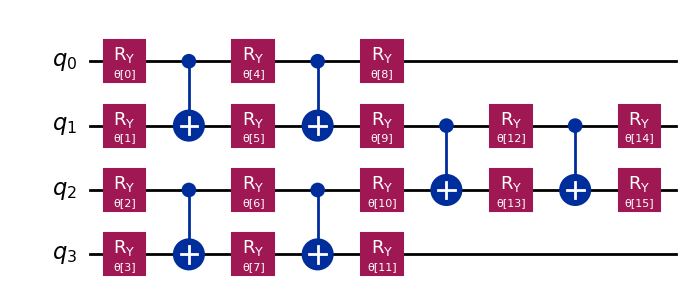

In [5]:
# Build a fresh Ansatz with N_LAYERS extra layers (mirrors LayerVQE final state)
demo_ansatz = Ansatz(problem.num_qubits)
for _ in range(N_LAYERS):
    demo_ansatz.add_layer()

qc_demo, theta_demo = ansatz_to_qiskit(demo_ansatz)
print(f'Qubits: {qc_demo.num_qubits}  |  Parameters: {demo_ansatz.param_count()}  |  Depth: {qc_demo.depth()}')
qc_demo.draw('mpl', fold=-1, style='iqp')

## Translate `problem.hamiltonian_terms` → `SparsePauliOp`

Each Hamiltonian term `(coeff, [q1, q2, …])` is a product of Z operators.
Qiskit uses **little-endian** Pauli strings: qubit 0 is the **rightmost** character.

In [6]:
def hamiltonian_to_sparse_pauli(problem: MaxCut) -> SparsePauliOp:
    """
    Build a SparsePauliOp from problem.hamiltonian_terms.

    Qiskit Pauli strings are little-endian: for n qubits, qubit q lives
    at string position (n - 1 - q).
    """
    n = problem.num_qubits
    pauli_list = []
    for coeff, qubits in problem.hamiltonian_terms:
        chars = ['I'] * n
        for q in qubits:
            chars[n - 1 - q] = 'Z'
        pauli_list.append((''.join(chars), coeff))
    return SparsePauliOp.from_list(pauli_list)


observable = hamiltonian_to_sparse_pauli(problem)
print('SparsePauliOp (Ising Hamiltonian):')
for term in observable:
    print(f'  {term.coeffs[0].real:+.3f} × {term.paulis[0]}')

SparsePauliOp (Ising Hamiltonian):
  -0.500 × IIIZ
  -0.500 × ZIII
  -0.500 × IIZZ
  -0.500 × IZZI
  -0.500 × ZZII


## IBM Quantum Backend

When `USE_REAL_HARDWARE = False` a **FakeNairobiV2** backend is used.
It uses the actual noise model of the Nairobi 7-qubit device so results
reflect realistic hardware behaviour without queue waiting times.

Set `USE_REAL_HARDWARE = True` and provide your `IBM_TOKEN` to run on a real device.

In [17]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token= IBM_TOKEN,
    overwrite=True
)

In [7]:
if USE_REAL_HARDWARE:
    # The legacy 'ibm_quantum' channel (hub/group/project instances like
    # 'ibm-q/open/main') has been retired. Use the 'ibm_cloud' channel.
    # `instance` must be a CRN; if blank, the service picks your default.
    service_kwargs = dict(channel='ibm_cloud', token=IBM_TOKEN)
    if IBM_INSTANCE:
        service_kwargs['instance'] = IBM_INSTANCE
    service = QiskitRuntimeService()

    backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=problem.num_qubits,
    )
    print(f'Real backend selected: {backend.name}  ({backend.num_qubits} qubits)')
else:
    from qiskit_ibm_runtime.fake_provider import FakeNairobiV2
    backend = FakeNairobiV2()
    print(f'Fake backend: {backend.name}  ({backend.num_qubits} qubits, noise-model simulation)')

print(f'Problem qubits needed: {problem.num_qubits}')

qiskit_runtime_service.__init__:WARNING:2026-06-02 14:40:27,626: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-02 14:40:28,146: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-02 14:40:30,533: Using instance: open-instance, plan: open


Real backend selected: ibm_marrakesh  (156 qubits)
Problem qubits needed: 4


## Transpile for Target Backend

The pass manager rewrites the circuit into the native gate set and qubit
connectivity of the backend.  We also apply the same layout to the observable
so the `Estimator` receives a consistent (circuit, observable) pair.

In [8]:
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)

# Transpile the demo circuit just to show statistics
isa_demo = pass_manager.run(qc_demo)
isa_obs  = observable.apply_layout(isa_demo.layout)

print(f'Original depth   : {qc_demo.depth()}')
print(f'Transpiled depth : {isa_demo.depth()}')
print(f'2Q gate count    : {isa_demo.num_nonlocal_gates()}')
print(f'Observable terms : {len(isa_obs)}')

Original depth   : 9
Transpiled depth : 32
2Q gate count    : 6
Observable terms : 5


## `IBMEstimatorBackend`: drop-in replacement for `QuimbSimulator`

This adapter class exposes the same `.expectation(params, ansatz, problem)` interface
as `QuimbSimulator`, but routes every call through IBM Runtime's `Estimator`.
It caches transpiled circuits so each new layer is compiled exactly once.

In [ ]:
import time, warnings
from qiskit_ibm_runtime import Batch, Session, EstimatorV2 as Estimator

class _UsageLimitReached(Exception):
    """Raised when IBM warns the instance is out of quota."""

class IBMEstimatorBackend:
    """
    Batch-aware, self-healing IBM Runtime backend for LayerVQE.

    Reactive failure handling:
      - Transient (1217 / session closed)      -> rotate batch, stay on hardware.
      - Usage limit met (emitted as a WARNING) -> cancel job, fall back to fake.
      - Job hangs past result timeout (cloud)  -> fall back to fake.
      - Repeated hard errors                   -> fall back to fake.
    """

    _TRANSIENT = ("1217", "session has been closed", "session is closed")
    _USAGE     = ("usage limit", "met its usage", "made available",
                  "will not run until", "not run until time")
    _QUOTA     = ("quota", "exceeded", "insufficient", "no remaining",
                  "limit reached", "forbidden", "403", "payment", "credit")

    def __init__(self, mode_factory, pass_manager, observable, shots=1024,
                 batch_budget_sec=480.0, max_batch_rotations=3,
                 fallback_backend=None, pm_builder=None, fallback_after=2,
                 result_timeout_sec=300.0):
        self._make_mode      = mode_factory
        self._pm             = pass_manager
        self._obs            = observable
        self._shots          = shots
        self._budget         = batch_budget_sec
        self._max_rot        = max_batch_rotations
        self._fb_backend     = fallback_backend
        self._pm_builder     = pm_builder
        self._fallback_after = fallback_after
        self._result_timeout = result_timeout_sec
        self._consec_fail    = 0
        self._on_fake        = False
        self._cache = {}
        self._mode = self._est = self._t0 = None
        self._open_new_mode()
        self._eval_idx       = 0      # increments on every expectation() call
        self._fallback_eval  = None   # eval index where hardware -> fake happened

    @property
    def on_fake(self):
        return self._on_fake
    @property
    def fallback_eval(self):
        """1-based evaluation index where it fell back to fake, or None."""
        return self._fallback_eval

    @property
    def total_evals(self):
        return self._eval_idx

    # ── lifecycle ─────────────────────────────────────────────────────────
    def _open_new_mode(self):
        self._close_mode()
        self._mode = self._make_mode()
        self._est  = Estimator(mode=self._mode)
        self._est.options.default_shots = self._shots
        self._t0   = time.time()
        print(f"  [batch] opened fresh execution context "
              f"({time.strftime('%H:%M:%S')})")

    def _close_mode(self):
        if self._mode is not None and not self._on_fake:
            try:
                self._mode.close()
            except Exception:
                pass
        self._mode = None

    def _rotate_if_needed(self):
        if not self._on_fake and self._t0 and (time.time() - self._t0) >= self._budget:
            print(f"  [batch] {self._budget:.0f}s budget reached — rotating")
            self._open_new_mode()

    def _switch_to_fake(self, reason=""):
        if self._on_fake:
            return
        print("\n" + "=" * 70)
        print("  [FALLBACK] hardware unusable — switching to local fake backend.")
        print(f"             reason: {reason[:200]}")
        print("             remaining results come from a NOISY LOCAL SIM.")
        print("=" * 70 + "\n")
        self._close_mode()
        self._on_fake = True
        self._pm   = self._pm_builder(self._fb_backend)
        self._cache.clear()
        self._mode = self._fb_backend
        self._est  = Estimator(mode=self._fb_backend)
        self._est.options.default_shots = self._shots
        self._t0   = None
        self._on_fake = True
        self._fallback_eval = self._eval_idx      # <-- mark the handoff point

    # ── ISA cache ─────────────────────────────────────────────────────────
    def _get_isa(self, ansatz):
        key = (ansatz.n_layers, ansatz.n_qubits, ansatz.param_count())
        if key not in self._cache:
            qc, _   = ansatz_to_qiskit(ansatz)
            isa_qc  = self._pm.run(qc)
            isa_obs = self._obs.apply_layout(isa_qc.layout)
            self._cache[key] = (isa_qc, isa_obs)
        return self._cache[key]

    # ── submit (captures the usage-limit warning) ─────────────────────────
    def _submit(self, isa_qc, isa_obs, params):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            job = self._est.run([(isa_qc, isa_obs, params)])
        for w in caught:
            if any(s in str(w.message).lower() for s in self._USAGE):
                try:
                    job.cancel()
                except Exception:
                    pass
                raise _UsageLimitReached(str(w.message))
        return job

    # ── result (timeout only applies to cloud jobs) ───────────────────────
    def _get_result(self, job):
        # Cloud RuntimeJobV2.result() accepts timeout; local PrimitiveJob.result()
        # does not. Only the cloud job can hang, so only it needs the backstop.
        if not self._on_fake and self._result_timeout:
            try:
                return job.result(timeout=self._result_timeout)
            except TypeError:
                pass   # this job type doesn't support timeout — fall through
        return job.result()

    # ── expectation ───────────────────────────────────────────────────────
    def expectation(self, params, ansatz, problem) -> float:
        isa_qc, isa_obs = self._get_isa(ansatz)
        self._rotate_if_needed()
        rotations_left = self._max_rot
        self._eval_idx += 1
        isa_qc, isa_obs = self._get_isa(ansatz)
        while True:
            try:
                job = self._submit(isa_qc, isa_obs, params)
                val = float(self._get_result(job)[0].data.evs)
                self._consec_fail = 0
                return val
            except _UsageLimitReached as e:
                if self._fb_backend is None:
                    raise
                self._switch_to_fake(reason=str(e))
                isa_qc, isa_obs = self._get_isa(ansatz)
                continue
            except Exception as e:
                if self._on_fake:
                    raise
                msg = str(e).lower()
                if any(t in msg for t in self._TRANSIENT) and rotations_left > 0:
                    rotations_left -= 1
                    print("  [batch] context closed mid-run — reopening")
                    self._open_new_mode()
                    continue
                self._consec_fail += 1
                hard_signal = (any(q in msg for q in self._QUOTA)
                               or "timed out" in msg or "timeout" in msg)
                if self._fb_backend is not None and (
                        hard_signal or self._consec_fail >= self._fallback_after):
                    self._switch_to_fake(reason=str(e))
                    isa_qc, isa_obs = self._get_isa(ansatz)
                    continue
                if self._fb_backend is None:
                    raise
                print(f"  [hw] hard failure {self._consec_fail}/"
                      f"{self._fallback_after} — retrying on new batch")
                self._open_new_mode()
                continue

    def sample_expectation(self, params, ansatz, problem, n_samples=1024):
        if n_samples != self._shots:
            self._shots = n_samples
            self._est.options.default_shots = n_samples
        return self.expectation(params, ansatz, problem)

    def close(self):
        self._close_mode()

print("IBMEstimatorBackend (reactive: warning-aware + fallback) defined.")

IBMEstimatorBackend (reactive: warning-aware + fallback) defined.


## Run L-VQE on IBM Hardware

All optimization jobs execute inside a single `Session` so they are batched
together in the queue with minimal inter-job overhead.

> **Tip:** increase `resilience_level` (0→2) on real hardware for error mitigation
> at the cost of more circuit executions per job.

In [15]:
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2
fallback_backend = FakeNairobiV2()        # always available, used only on fallback

def make_execution_mode():
    return Batch(backend=backend) if USE_REAL_HARDWARE else Session(backend=backend)

def build_pm(bk):
    return generate_preset_pass_manager(backend=bk, optimization_level=1)

ibm_sim = IBMEstimatorBackend(
    mode_factory=make_execution_mode,
    pass_manager=pass_manager,
    observable=observable,
    shots=1024,
    batch_budget_sec=480.0,
    fallback_backend=fallback_backend,
    pm_builder=build_pm,
    fallback_after=2,        # 2 hard failures in a row -> go local
)

try:
    lvqe = LayerVQE(
        problem=problem, simulator=ibm_sim, optimizer_class=OPTIMIZER,
        n_layers=N_LAYERS, k_per_layer=K_PER_LAYER, k_final=K_FINAL,
        use_sampling=False, record_loss=True,
    )
    result = lvqe.run()
finally:
    ibm_sim.close()

if ibm_sim.on_fake:
    print("\n NOTE: optimization finished on the LOCAL fake backend, "
          "not the real device.")

  [batch] opened fresh execution context (15:07:20)
Starting L-VQE: 1 layers, 30 iter/layer, 100 final iter
Mode: exact expectation

Layer 0: 

Optimizer: COBYLA | rhobeg=1.0, max_iter=30


COBYLA:   0%|          | 0/30 [00:00<?, ?it/s]


  [FALLBACK] hardware unusable — switching to local fake backend.
             reason: This instance has met its usage limit. Workloads will not run until time ismade available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2
             remaining results come from a NOISY LOCAL SIM.



COBYLA: 100%|██████████| 30/30 [00:02<00:00, 11.81it/s, best_E=+1.4922]


Total evaluations: 30
layer 0: energy=+1.4922, approx_ratio=+0.9980

Final layer — 100 iterations (final)
Optimizer: COBYLA | rhobeg=1.0, max_iter=100


COBYLA: 100%|██████████| 100/100 [00:01<00:00, 71.36it/s, best_E=+1.5000]

Total evaluations: 100
layer 1: energy=+1.5000, approx_ratio=+1.0000

 NOTE: optimization finished on the LOCAL fake backend, not the real device.


## Results

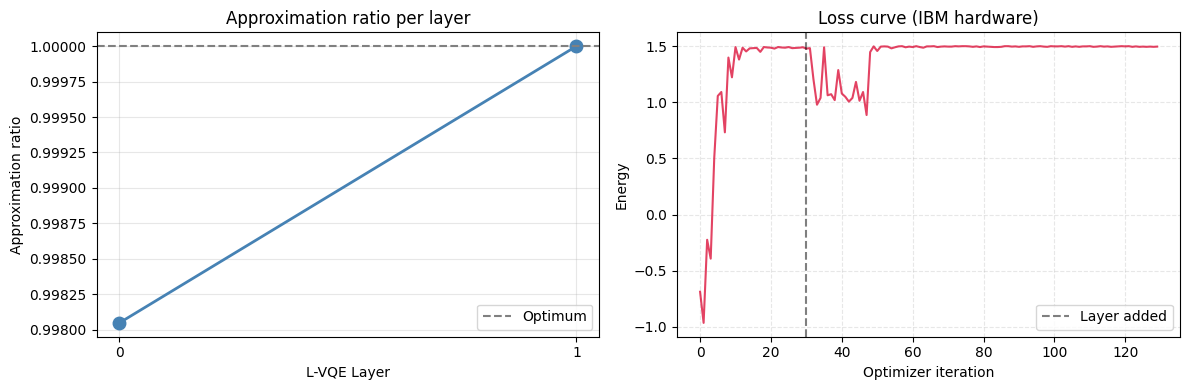

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Approximation ratio per layer ──
ax = axes[0]
layers = result['history']['layer']
ratios = result['history']['approx_ratio']
ax.plot(layers, ratios, 'o-', lw=2, ms=9, color='steelblue')
ax.axhline(1.0, ls='--', color='gray', label='Optimum')
ax.set_xlabel('L-VQE Layer')
ax.set_ylabel('Approximation ratio')
ax.set_title('Approximation ratio per layer')
ax.set_xticks(layers)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Loss curve ──
ax = axes[1]
loss_per_layer = result['history']['optimizer_loss']
if any(len(l) > 0 for l in loss_per_layer):
    all_loss = np.concatenate(loss_per_layer)
    ax.plot(all_loss, color='crimson', lw=1.5, alpha=0.8)
    # Mark layer boundaries
    boundary = 0
    for i, layer_loss in enumerate(loss_per_layer[:-1]):
        boundary += len(layer_loss)
        ax.axvline(boundary, ls='--', color='black', alpha=0.5,
                   label='Layer added' if i == 0 else '')
    ax.set_xlabel('Optimizer iteration')
    ax.set_ylabel('Energy')
    ax.set_title('Loss curve (IBM hardware)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No loss recorded\n(set record_loss=True)',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

## Decode the solution — sample from the optimized circuit

We bind the best parameters and sample bitstrings from the final ansatz.
Sampling runs locally with `StatevectorSampler` (noiseless) to get clean
probability estimates.  The same call works on IBM hardware by replacing
`StatevectorSampler` with `Sampler(mode=session)` (see the commented block).

In [17]:
final_ansatz: Ansatz = result['final_ansatz']
final_params: np.ndarray = result['final_params']

# Build a measurement circuit from the (non-transpiled) final ansatz
qc_final, theta_final = ansatz_to_qiskit(final_ansatz)
qc_meas = qc_final.copy()
qc_meas.measure_all()

# Bind optimized parameters
param_dict = {theta_final[i]: final_params[i] for i in range(len(final_params))}
bound_circuit = qc_meas.assign_parameters(param_dict)

# ── Local noiseless sampling ──────────────────────────────────────────────────
local_sampler = StatevectorSampler()
job = local_sampler.run([bound_circuit], shots=4096)
counts_raw = job.result()[0].data.meas.get_counts()

# ── On-hardware alternative (uncomment to use) ────────────────────────────────
# isa_meas = pass_manager.run(bound_circuit)   # transpile bound circuit
# with Session(backend=backend) as session:
#     hw_sampler = Sampler(mode=session)
#     hw_sampler.options.default_shots = 4096
#     job = hw_sampler.run([isa_meas])
#     counts_raw = job.result()[0].data.meas.get_counts()

print(f'Unique bitstrings sampled: {len(counts_raw)}')

Unique bitstrings sampled: 8


In [18]:
# Decode bitstrings → MaxCut assignments
# The circuit uses qubits 0 … n-2 (symmetry: node 0 is always in partition 0)
# Qiskit bitstring ordering: bitstring[0] = qubit n-2, bitstring[-1] = qubit 0

n_qubits = problem.num_qubits
total_shots = sum(counts_raw.values())
solutions = []

for bitstring, count in sorted(counts_raw.items(), key=lambda x: -x[1]):
    # Qiskit bitstring is big-endian: reverse to get qubit 0 at index 0
    measured_bits = [int(b) for b in reversed(bitstring)]  # length = n_qubits
    full_assignment = [0] + measured_bits                   # prepend pinned qubit 0
    cut_value  = problem.evaluate(full_assignment)
    approx_r   = cut_value / problem.best_known_value
    probability = count / total_shots
    solutions.append((full_assignment, cut_value, approx_r, probability))

print(f'Top 5 solutions (best cut = {problem.best_known_value}):\n')
print(f'{"Assignment":<40} {"Cut":>6} {"Approx ratio":>14} {"Prob %":>8}')
print('-' * 72)
for assignment, cut, ar, prob in solutions[:5]:
    print(f'{str(assignment):<40} {cut:>6.0f} {ar:>14.4f} {prob*100:>7.1f}%')

Top 5 solutions (best cut = 4.0):

Assignment                                  Cut   Approx ratio   Prob %
------------------------------------------------------------------------
[0, 0, 1, 0, 1]                               4         1.0000    69.4%
[0, 1, 0, 0, 1]                               4         1.0000    22.2%
[0, 1, 1, 0, 1]                               4         1.0000     8.2%
[0, 1, 1, 1, 1]                               2         0.5000     0.1%
[0, 0, 0, 0, 1]                               2         0.5000     0.0%


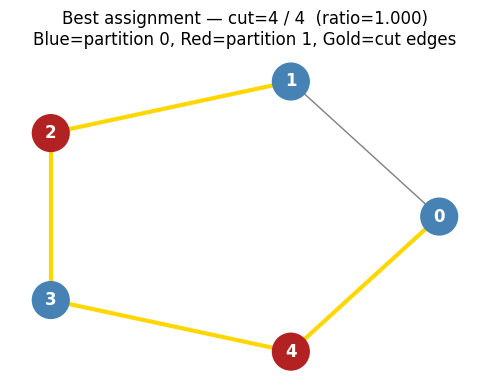

In [19]:
# Visualise the best assignment on the graph
best_assignment, best_cut, best_ar, _ = max(solutions, key=lambda x: x[1])

color_map = ['steelblue' if best_assignment[node] == 0 else 'firebrick'
             for node in G.nodes()]

cut_edges    = [(u, v) for u, v in G.edges() if best_assignment[u] != best_assignment[v]]
noncut_edges = [(u, v) for u, v in G.edges() if best_assignment[u] == best_assignment[v]]

fig, ax = plt.subplots(figsize=(5, 4))
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color_map, node_size=700)
nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=cut_edges,    ax=ax, edge_color='gold',  width=3)
nx.draw_networkx_edges(G, pos, edgelist=noncut_edges, ax=ax, edge_color='gray',  width=1)
ax.set_title(
    f'Best assignment — cut={best_cut:.0f} / {problem.best_known_value:.0f}'
    f'  (ratio={best_ar:.3f})\n'
    f'Blue=partition 0, Red=partition 1, Gold=cut edges'
)
ax.axis('off')
plt.tight_layout()
plt.show()

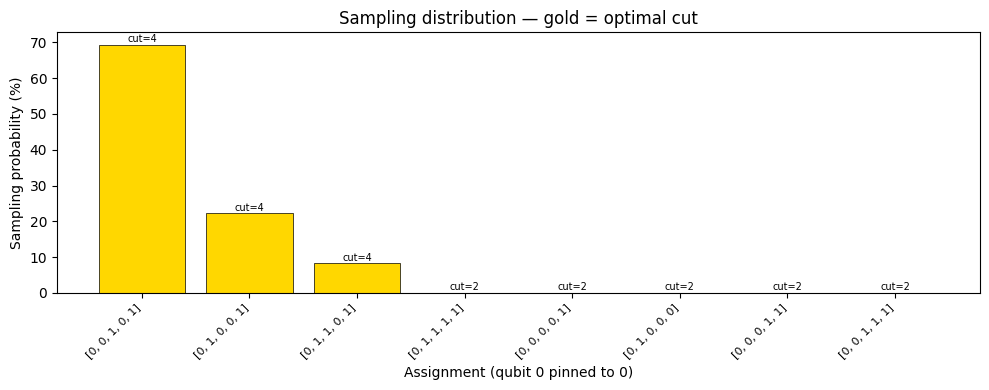

Optimal assignments (cut=4.0): 3 distinct bitstrings
Probability mass on optimal: 99.8%


In [20]:
# Probability histogram — top bitstrings
top_n = min(10, len(solutions))
top_solutions = solutions[:top_n]

labels     = [str(s[0]) for s in top_solutions]
probs      = [s[3] * 100 for s in top_solutions]
cuts       = [s[1] for s in top_solutions]
bar_colors = ["gold" if c == problem.best_known_value else "steelblue" for c in cuts]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(top_n), probs, color=bar_colors, edgecolor="black", lw=0.5)
ax.set_xticks(range(top_n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Assignment (qubit 0 pinned to 0)")
ax.set_ylabel("Sampling probability (%)")
ax.set_title("Sampling distribution — gold = optimal cut")
for bar, cut in zip(bars, cuts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"cut={cut:.0f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

print(f"Optimal assignments (cut={problem.best_known_value}): "
      f"{sum(1 for s in solutions if s[1] == problem.best_known_value)} distinct bitstrings")
print(f"Probability mass on optimal: "
      f"{sum(s[3] for s in solutions if s[1] == problem.best_known_value)*100:.1f}%")